## Task 1: Data Loading, EDA & Preprocessing


### Load the dataset

In [2]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Load Dataset
data = load_breast_cancer(as_frame=True)

# Features and Target
X = data.data
y = data.target

# Shape
print("Shape of X:")
print(X.shape)

# Target Counts
print("\nTarget Value Counts:")
print(y.value_counts())

# Statistical Summary
print("\nDataset Description:")
print(X.describe())

Shape of X:
(569, 30)

Target Value Counts:
target
1    357
0    212
Name: count, dtype: int64

Dataset Description:
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.0797

### Class distribution plot

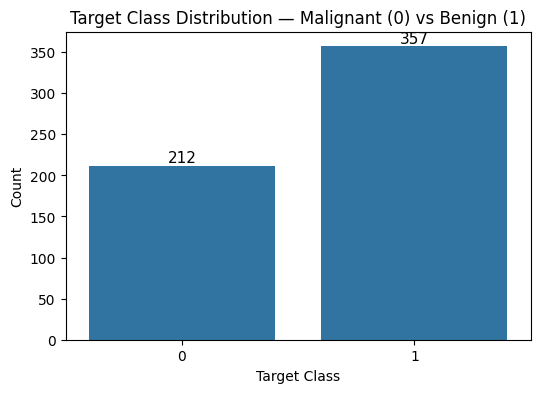

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
ax = sns.countplot(x=y)

plt.title("Target Class Distribution — Malignant (0) vs Benign (1)")
plt.xlabel("Target Class")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.show()

Observation :

The target variable shows a mild class imbalance:

- **Malignant (0):** 212 samples
- **Benign (1):** 357 samples

Although the classes are not perfectly balanced, the imbalance is relatively small (212 vs 357). For a dataset of 569 samples, this generally does **not** require special handling such as oversampling or undersampling. Standard binary classification algorithms can usually perform well on this dataset. However, evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC should be considered in addition to Accuracy.

### Feature correlation heatmap

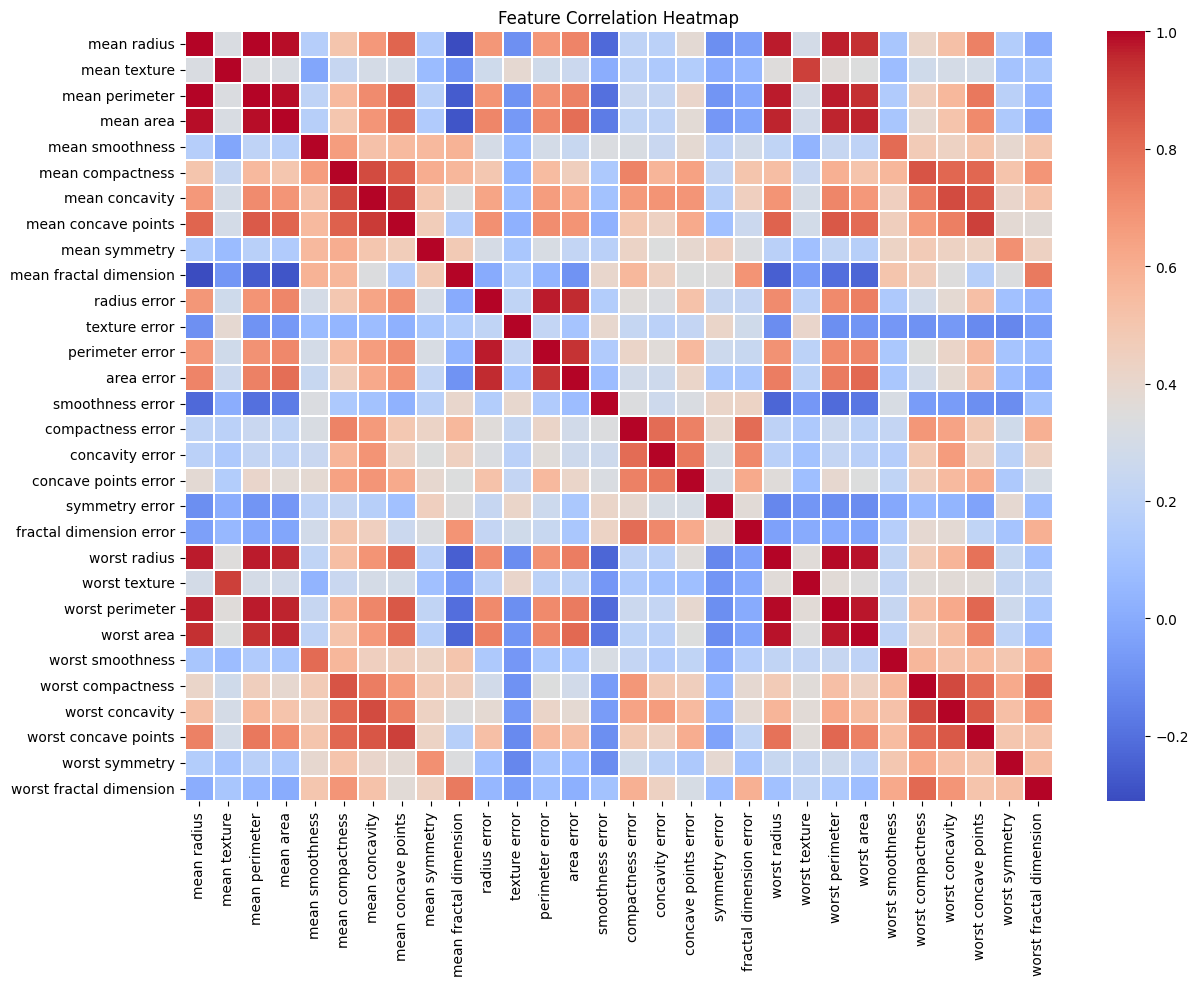

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix
corr_matrix = X.corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    linewidths=0.3
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [5]:
pairs = [
    ('mean radius', 'mean perimeter'),
    ('mean radius', 'mean area'),
    ('mean perimeter', 'mean area')
]

for f1, f2 in pairs:
    print(f"{f1} vs {f2}: {corr_matrix.loc[f1, f2]:.3f}")

mean radius vs mean perimeter: 0.998
mean radius vs mean area: 0.987
mean perimeter vs mean area: 0.987


Interpretation :

The feature correlation heatmap shows that several features are strongly correlated with each other.

Some highly correlated feature pairs include:

- **radius_mean and perimeter_mean**
- **radius_mean and area_mean**
- **perimeter_mean and area_mean**

These features have a strong positive correlation because they represent related geometric properties of cell nuclei. For example, as the radius of a cell nucleus increases, its perimeter and area also tend to increase.

High inter-feature correlation is more problematic for traditional linear models such as Linear Regression and Logistic Regression because it can cause **multicollinearity**, making model coefficients unstable and difficult to interpret.

For **neural networks**, high correlation is generally less problematic because the network learns weights for the input features and can learn nonlinear relationships between them. Therefore, correlated features do not necessarily cause model instability. However, highly correlated features can still contain redundant information and may increase model complexity.

### Train / test split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (455, 30)
X_test shape : (114, 30)
y_train shape: (455,)
y_test shape : (114,)


In [9]:
print("Original class distribution:")
print(y.value_counts(normalize=True))

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Original class distribution:
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64

Training class distribution:
target
1    0.626374
0    0.373626
Name: proportion, dtype: float64

Testing class distribution:
target
1    0.631579
0    0.368421
Name: proportion, dtype: float64


In [10]:
print("Original:")
print(y.value_counts())

print("\nTraining:")
print(y_train.value_counts())

print("\nTesting:")
print(y_test.value_counts())

Original:
target
1    357
0    212
Name: count, dtype: int64

Training:
target
1    285
0    170
Name: count, dtype: int64

Testing:
target
1    72
0    42
Name: count, dtype: int64


In [11]:
print("Class ratios:")

print("\nOriginal:")
print((y.value_counts(normalize=True) * 100).round(2))

print("\nTraining:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Class ratios:

Original:
target
1    62.74
0    37.26
Name: proportion, dtype: float64

Training:
target
1    62.64
0    37.36
Name: proportion, dtype: float64

Testing:
target
1    63.16
0    36.84
Name: proportion, dtype: float64


Interpretation :

The dataset was split into 80% training data and 20% testing data using `train_test_split()` with `random_state=42` and `stratify=y`.

- **Training set:** 455 samples
- **Testing set:** 114 samples
- **Features:** 30

The `stratify=y` parameter preserved the original class distribution in both the training and testing sets. The original dataset contains approximately **63% Benign (1)** and **37% Malignant (0)** samples. The training and testing sets maintain nearly the same 63/37 class ratio.

Therefore, stratification was successful and ensures that both sets are representative of the original target class distribution.

### Apply StandardScaler

In [12]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data
scaler.fit(X_train)

# Transform training and testing data
X_train_sc = scaler.transform(X_train)
X_test_sc = scaler.transform(X_test)

# Verify mean
print("Mean of X_train_sc:")
print(X_train_sc.mean(axis=0).round(2))

# Verify standard deviation
print("\nStandard deviation of X_train_sc:")
print(X_train_sc.std(axis=0).round(2))

Mean of X_train_sc:
[-0.  0. -0. -0.  0. -0. -0.  0. -0.  0. -0. -0.  0.  0. -0. -0.  0. -0.
  0.  0.  0. -0. -0.  0.  0. -0.  0. -0. -0.  0.]

Standard deviation of X_train_sc:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


The StandardScaler is fitted only on the training data because the scaler learns the mean and standard deviation of each feature from the data.

If we fit the scaler on the test data, information from the test set would be used during the model preparation process. This causes **data leakage**, because the test set is supposed to represent unseen data.

Therefore, we:

1. Fit the scaler on `X_train` only.
2. Transform `X_train` using the learned parameters.
3. Transform `X_test` using the same parameters learned from `X_train`.

This ensures that the test data remains completely unseen during training and provides a more reliable estimate of model performance.

### WHY scaling for neural networks

##### Why Scaling is Important for Neural Networks

Feature scaling is important for neural networks because they are trained using gradient-based optimization algorithms such as **SGD (Stochastic Gradient Descent)** and **Adam**.

These optimizers generally converge **faster and more stably** when all input features are on a similar scale.

Without scaling, features can have very different ranges. For example:

- **area-related features** can have values up to approximately **2500**.
- **fractal_dimension_mean** has a much smaller range of approximately **0.05–0.10**.

Because of this large difference in scale, features with larger numerical values can have a much stronger influence on the early gradient updates, while smaller-scale features may contribute very little. This can result in **slow, unstable, or biased learning** and make optimization more difficult.

Using `StandardScaler` transforms each feature so that it has approximately:

- **Mean = 0**
- **Standard deviation = 1**

Therefore, StandardScaler removes the disparity between feature scales and allows the neural network's optimizer to learn from all input features more effectively.

##### Conclusion :

Scaling helps neural networks achieve **faster convergence, more stable gradient updates, and more effective learning** by putting all input features on a comparable scale.

## Task 2 : Single-Layer Perceptron (SLP) — Baseline Model


### Build the SLP

In [14]:
import tensorflow as tf
from tensorflow import keras

model_slp = keras.Sequential([
    keras.layers.Dense(
        1,
        activation='sigmoid',
        input_shape=(30,)
    )
])

C:\Users\JANKI DHOLARIYA\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model_slp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

### Compile the SLP

In [16]:
model_slp.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model_slp.summary()

# Confirm total parameters
print("Total parameters:", model_slp.count_params())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

Total parameters: 31


Why Binary Cross-Entropy?

Binary Cross-Entropy is the appropriate loss function for this problem because the target variable contains two classes: **Malignant (0)** and **Benign (1)**.

The SLP uses a **sigmoid activation function**, which produces a probability between 0 and 1. Binary Cross-Entropy measures how close these predicted probabilities are to the actual binary labels.

It is based on the **log-likelihood** of the predicted probability given the true class. The model is penalized strongly when it is confident but makes an incorrect prediction.

The binary cross-entropy loss is:

**Loss = -[y log(p) + (1-y) log(1-p)]**

where:
- `y` is the true binary label (0 or 1)
- `p` is the predicted probability

Binary Cross-Entropy is preferred over **Mean Squared Error (MSE)** for binary classification because MSE is primarily designed for regression problems and can result in less effective gradient behavior when used with sigmoid outputs.

Therefore, `binary_crossentropy` is the appropriate loss function for training this binary classification SLP.

### Train the SLP

In [17]:
# Train the SLP
history_slp = model_slp.fit(
    X_train_sc,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Check stored metrics
print(history_slp.history.keys())

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8093 - loss: 0.4281 - val_accuracy: 0.8478 - val_loss: 0.3745
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8631 - loss: 0.3807 - val_accuracy: 0.8478 - val_loss: 0.3397
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9071 - loss: 0.3416 - val_accuracy: 0.8913 - val_loss: 0.3120
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9144 - loss: 0.3107 - val_accuracy: 0.8913 - val_loss: 0.2898
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9144 - loss: 0.2862 - val_accuracy: 0.8913 - val_loss: 0.2720
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9193 - loss: 0.2658 - val_accuracy: 0.9130 - val_loss: 0.2578
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9291 - loss: 0.2487 - val_accuracy: 0.9130 - val_loss: 0.2464
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9315 - loss: 0.2348 - val_accuracy: 0.9130 - val_loss

### Plot SLP training curves

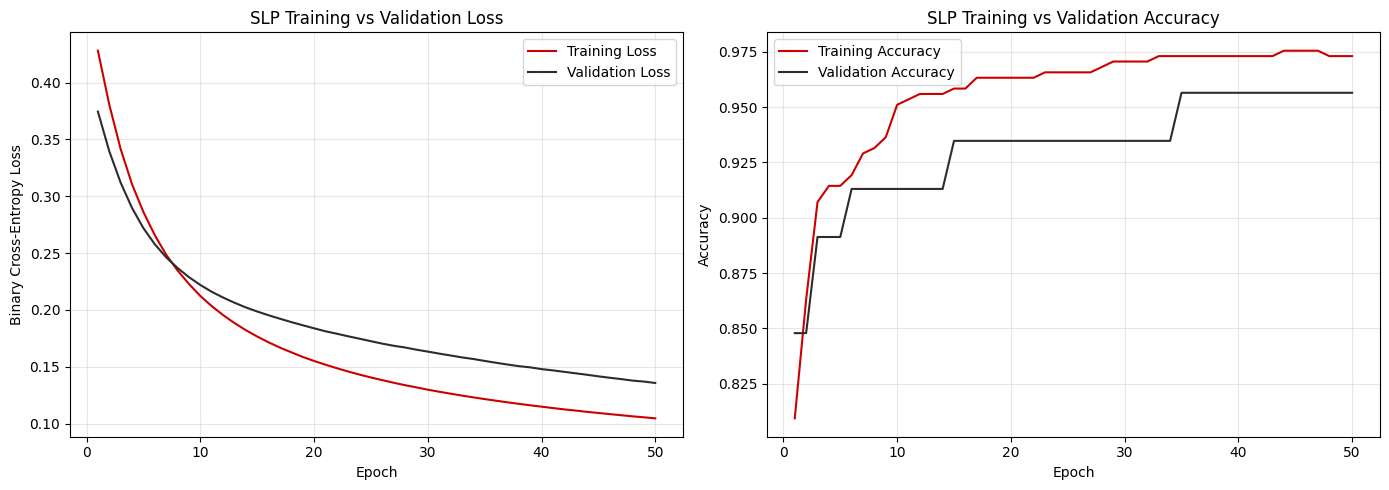

In [21]:
import matplotlib.pyplot as plt

history = history_slp.history
epochs = range(1, len(history['loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Plot

axes[0].plot(
    epochs,
    history['loss'],
    color='#CC0000',
    label='Training Loss'
)
axes[0].plot(
    epochs,
    history['val_loss'],
    color='#2C2C2C',
    label='Validation Loss'
)

axes[0].set_title('SLP Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy Plot

axes[1].plot(
    epochs,
    history['accuracy'],
    color='#CC0000',
    label='Training Accuracy'
)

axes[1].plot(
    epochs,
    history['val_accuracy'],
    color='#2C2C2C',
    label='Validation Accuracy'
)

axes[1].set_title('SLP Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Interpretation of SLP Training Curves :

The training and validation curves show how the Single Layer Perceptron learns over the 50 epochs.

Loss :

The training loss generally decreases as the number of epochs increases, indicating that the model is learning from the training data. The validation loss follows a similar trend and becomes relatively stable, suggesting that the model converges smoothly.

There is no large or continuously increasing gap between training and validation loss, indicating that there is no strong evidence of severe overfitting.

Accuracy :

The training and validation accuracy increase and become relatively stable as training progresses. The validation accuracy remains reasonably close to the training accuracy, which indicates that the model is able to generalize to unseen validation samples.

Overall :

The SLP appears to converge reasonably smoothly. A small difference between training and validation performance is expected, but a large and continuously increasing gap would indicate overfitting. Based on the curves, the SLP shows stable learning with no major signs of overfitting.

### Evaluate the SLP

In [24]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Evaluate SLP
slp_loss, slp_acc = model_slp.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)
print("SLP Test Accuracy:", slp_acc)

# Predictions
y_pred_slp = (
    model_slp.predict(X_test_sc, verbose=0) > 0.5
).astype(int).ravel()

# Classification Report
print("\nSLP Classification Report:")
print(classification_report(y_test, y_pred_slp))



SLP Test Accuracy: 0.9298245906829834

SLP Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91        42
           1       0.97      0.92      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



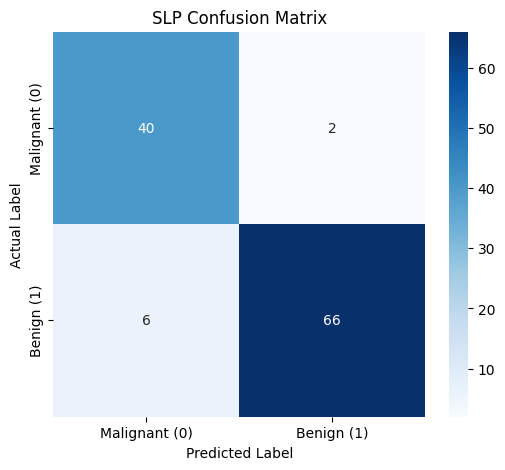


Result stored for Task 7:
{'Model': 'SLP', 'Test Accuracy': 0.9298245906829834}


In [25]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_slp)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Malignant (0)', 'Benign (1)'],
    yticklabels=['Malignant (0)', 'Benign (1)']
)

plt.title('SLP Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

# Store result for Task 7
slp_results = {
    'Model': 'SLP',
    'Test Accuracy': slp_acc
}

print("\nResult stored for Task 7:")
print(slp_results)

SLP Test Evaluation :

The trained Single Layer Perceptron was evaluated on the unseen test set of 114 samples.

The test accuracy indicates the proportion of test samples that were classified correctly. The classification report provides precision, recall, and F1-score for both Malignant (0) and Benign (1) classes.

The confusion matrix provides a detailed view of correct and incorrect predictions. The diagonal cells represent correct predictions, while the off-diagonal cells represent misclassifications.

For this medical classification problem, recall is particularly important because incorrectly classifying a malignant case as benign can be more serious than some other types of errors. Therefore, the model should not be evaluated using accuracy alone; precision, recall, F1-score, and the confusion matrix should also be considered.

### SLP limitations — Markdown

SLP Limitations :

The fundamental limitation of a **Single Layer Perceptron (SLP)** is that it can only learn **linearly separable decision boundaries**.

In this problem, the SLP has 30 input features and one output neuron. Therefore, it can learn only a **single linear decision boundary (one hyperplane) in the 30-dimensional feature space** to separate Malignant (0) and Benign (1) cases.

However, breast cancer classification is unlikely to be perfectly linearly separable because the relationships between the cell features and the target class can be complex and nonlinear.

Therefore, although the SLP can provide a useful baseline, it may not capture all the complex patterns in the dataset.

Conclusion :

The SLP provides a **realistic baseline model** for this binary classification task, but its performance may be improved by using a **Multi-Layer Perceptron (MLP)** with one or more hidden layers. Hidden layers allow the MLP to learn nonlinear relationships and more complex decision boundaries.

This limitation motivates the transition to the **MLP in Task 3**.

## Task 3: Multi-Layer Perceptron (MLP) — Activation Functions


### Build the MLP (ReLU)

In [27]:
model_mlp = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(30,)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model_mlp.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
total_params_manual = (
    30 * 64 + 64
    + 64 * 32 + 32
    + 32 * 1 + 1
)

print("Manually calculated parameters:", total_params_manual)
print("Model parameters:", model_mlp.count_params())

Manually calculated parameters: 4097
Model parameters: 4097


MLP Architecture and Parameter Calculation :

The Multi-Layer Perceptron (MLP) contains two hidden layers followed by a single sigmoid output neuron.

Architecture :

- Input layer: **30 features**
- Hidden Layer 1: **64 neurons with ReLU**
- Hidden Layer 2: **32 neurons with ReLU**
- Output Layer: **1 neuron with Sigmoid**

The total number of trainable parameters is calculated as:

**First layer:**
30 × 64 + 64 = **1,984**

**Second layer:**
64 × 32 + 32 = **2,080**

**Output layer:**
32 × 1 + 1 = **33**

Therefore:

**Total parameters = 1,984 + 2,080 + 33 = 4,097**

The manually calculated total matches the value reported by `model_mlp.summary()`.

The ReLU activation functions in the hidden layers allow the MLP to learn **nonlinear relationships and complex decision boundaries**, overcoming the main limitation of the Single Layer Perceptron.

### WHY hidden layers — Markdown

Why Hidden Layers?

Hidden layers are important because they allow a neural network to learn **non-linear relationships** between input features.

Each `Dense` layer learns a transformation of its inputs using learned weights, biases, and a non-linear activation function such as **ReLU**.

In this MLP, the two hidden layers allow the network to combine and learn increasingly complex interactions between the 30 input features:

**30 Input Features → 64 ReLU Neurons → 32 ReLU Neurons → 1 Sigmoid Output**

The first hidden layer learns intermediate patterns from the original features. The second hidden layer can then combine these learned patterns to represent more complex relationships before making the final prediction.

According to the **Universal Approximation Theorem**, a neural network with a single hidden layer and a sufficient number of neurons can theoretically approximate a very wide class of continuous functions. However, in practice, using multiple hidden layers can provide a more efficient representation of complex functions.

For tabular medical data, two hidden layers can sometimes provide a useful balance between model capacity and computational complexity. Adding more layers creates a **deeper feature hierarchy**, where later layers can build higher-level representations from patterns learned by earlier layers.

Conclusion :

Hidden layers allow the MLP to learn **non-linear decision boundaries and complex feature interactions**, which is a major advantage over the Single Layer Perceptron.

### Compile and train MLP (ReLU)

In [ ]:
# Compile MLP
model_mlp.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train MLP
history_mlp = model_mlp.fit(
    X_train_sc,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

print(history_mlp.history.keys())

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6259 - loss: 0.6518 - val_accuracy: 0.8913 - val_loss: 0.4870
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9511 - loss: 0.3894 - val_accuracy: 0.9130 - val_loss: 0.3289
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9535 - loss: 0.2464 - val_accuracy: 0.9348 - val_loss: 0.2423
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9560 - loss: 0.1665 - val_accuracy: 0.9348 - val_loss: 0.1943
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9682 - loss: 0.1252 - val_accuracy: 0.9348 - val_loss: 0.1642
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9780 - loss: 0.1019 - val_accuracy: 0.9348 - val_loss: 0.1421
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9780 - loss: 0.0875 - val_accuracy: 0.9565 - val_loss: 0.1231
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9780 - loss: 0.0770 - val_accuracy: 0.9565 - 

### Compare activation functions

In [30]:
model_mlp_tanh = keras.Sequential([
    keras.layers.Dense(64, activation='tanh', input_shape=(30,)),
    keras.layers.Dense(32, activation='tanh'),
    keras.layers.Dense(1, activation='sigmoid')
])

In [34]:
model_mlp_tanh.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_tanh = model_mlp_tanh.fit(
    X_train_sc,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 1.0000 - loss: 1.0229e-04 - val_accuracy: 0.9565 - val_loss: 0.1880
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 1.1364e-04 - val_accuracy: 0.9783 - val_loss: 0.1898
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 1.2819e-04 - val_accuracy: 0.9783 - val_loss: 0.2123
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 2.2040e-04 - val_accuracy: 0.9783 - val_loss: 0.2098
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 1.7074e-04 - val_accuracy: 0.9565 - val_loss: 0.2084
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 6.5989e-05 - val_accuracy: 0.9565 - val_loss: 0.2012
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 4.3512e-05 - val_accuracy: 0.9783 - val_loss: 0.1917
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 3.2

In [35]:
model_mlp_sigmoid = keras.Sequential([
    keras.layers.Dense(64, activation='sigmoid', input_shape=(30,)),
    keras.layers.Dense(32, activation='sigmoid'),
    keras.layers.Dense(1, activation='sigmoid')
])

In [36]:
model_mlp_sigmoid.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_sigmoid = model_mlp_sigmoid.fit(
    X_train_sc,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6406 - loss: 0.6151 - val_accuracy: 0.5000 - val_loss: 0.6677
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6846 - loss: 0.5392 - val_accuracy: 0.6957 - val_loss: 0.5864
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8117 - loss: 0.4707 - val_accuracy: 0.8261 - val_loss: 0.5224
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8753 - loss: 0.4035 - val_accuracy: 0.8261 - val_loss: 0.4558
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9144 - loss: 0.3447 - val_accuracy: 0.8261 - val_loss: 0.3993
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9193 - loss: 0.2931 - val_accuracy: 0.8696 - val_loss: 0.3493
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9364 - loss: 0.2512 - val_accuracy: 0.8696 - val_loss: 0.3092
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9389 - loss: 0.2188 - val_accuracy: 0.8913 -

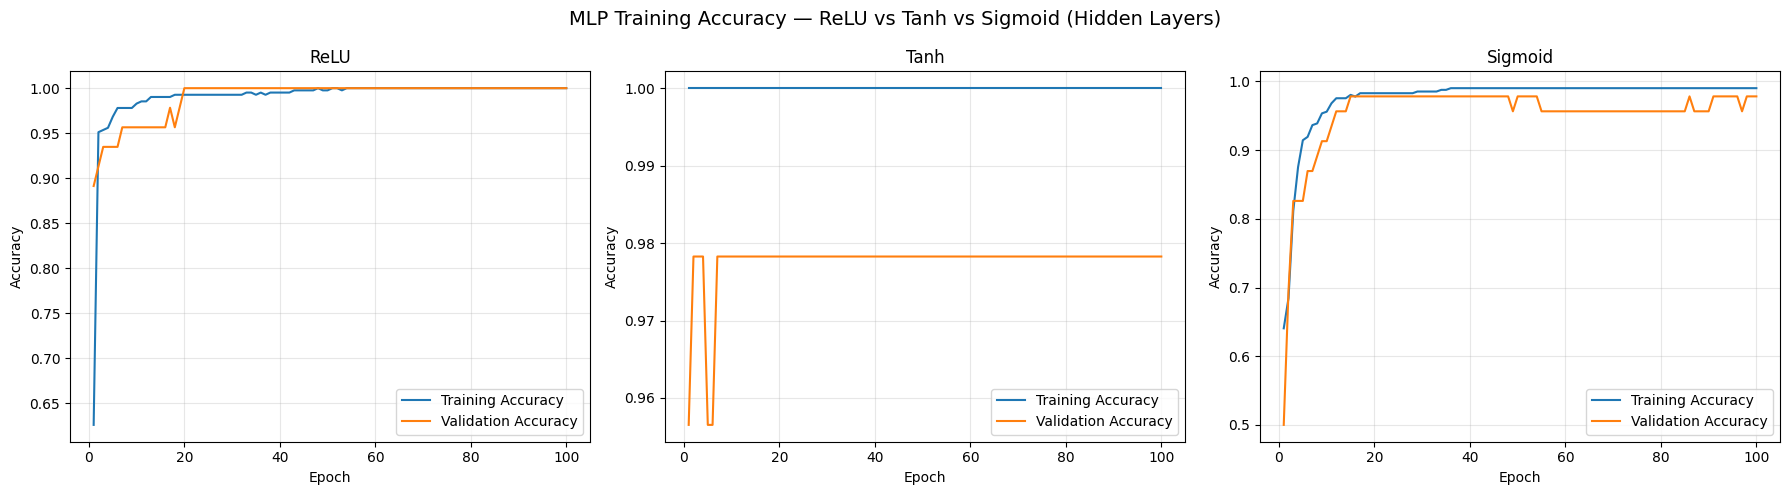

In [38]:
import matplotlib.pyplot as plt
epochs = range(1, 101)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ReLU

axes[0].plot(
    epochs,
    history_mlp.history['accuracy'],
    label='Training Accuracy'
)
axes[0].plot(
    epochs,
    history_mlp.history['val_accuracy'],
    label='Validation Accuracy'
)
axes[0].set_title('ReLU')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)


# Tanh

axes[1].plot(
    epochs,
    history_tanh.history['accuracy'],
    label='Training Accuracy'
)
axes[1].plot(
    epochs,
    history_tanh.history['val_accuracy'],
    label='Validation Accuracy'
)
axes[1].set_title('Tanh')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Sigmoid

axes[2].plot(
    epochs,
    history_sigmoid.history['accuracy'],
    label='Training Accuracy'
)
axes[2].plot(
    epochs,
    history_sigmoid.history['val_accuracy'],
    label='Validation Accuracy'
)

axes[2].set_title('Sigmoid')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(alpha=0.3)

fig.suptitle(
    'MLP Training Accuracy — ReLU vs Tanh vs Sigmoid (Hidden Layers)',
    fontsize=14
)

plt.tight_layout()
plt.show()

### Activation functions — Markdown

Activation Functions — ReLU vs Tanh vs Sigmoid :

The three activation functions used in the hidden layers have different properties and affect how the neural network learns.

1. ReLU (Rectified Linear Unit) :

ReLU is defined as:

**ReLU(x) = max(0, x)**

ReLU outputs 0 for negative inputs and the input value itself for positive inputs.

**Advantages:**
- It is computationally simple and fast.
- It generally provides faster convergence on many tabular datasets.
- For positive inputs, it does not suffer from the traditional vanishing-gradient problem.

**Limitation:**
- ReLU has a zero gradient for negative inputs.
- If a neuron consistently receives negative inputs, it may stop learning. This is known as the **dying ReLU** problem.

2. Tanh :

Tanh produces values between **-1 and +1**.

**Advantages:**
- It is **zero-centred**, unlike Sigmoid.
- It can represent nonlinear relationships effectively.

**Limitation:**
- For very large positive or negative inputs, Tanh saturates.
- Its gradient becomes very small in these regions, which can cause the **vanishing-gradient problem**, especially in deeper networks.

3. Sigmoid :

Sigmoid produces values between **0 and 1**.

**Advantages:**
- It is useful for the final output layer of a binary classification model because it produces a probability between 0 and 1.

**Limitations in hidden layers:**
- It is not zero-centred.
- It can saturate for large positive or negative inputs.
- This can produce very small gradients and cause a severe **vanishing-gradient problem** in deeper networks.
- Therefore, Sigmoid is generally better suited to the **output layer for binary classification** rather than hidden layers.

##### Dataset-Specific Conclusion :

Based on the training and validation accuracy curves, **ReLU performed best on this dataset**. It achieved strong validation accuracy and converged faster and more consistently than Tanh and Sigmoid.

This is consistent with the typical behaviour of ReLU in neural networks: it provides better gradient flow for positive activations and usually allows faster optimization than saturating activation functions such as Tanh and Sigmoid.

Therefore, **ReLU is the preferred hidden-layer activation function for this MLP**, while Sigmoid is retained in the final output layer for binary classification.

### Evaluate best MLP

In [39]:
# Evaluate best MLP
mlp_loss, mlp_acc = model_mlp.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print("Best MLP Test Accuracy:", mlp_acc)

# Generate predictions
y_pred_mlp = (
    model_mlp.predict(X_test_sc, verbose=0) > 0.5
).astype(int).ravel()

# Classification report
print("\nMLP Classification Report:")
print(classification_report(y_test, y_pred_mlp))


Best MLP Test Accuracy: 0.9649122953414917

MLP Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



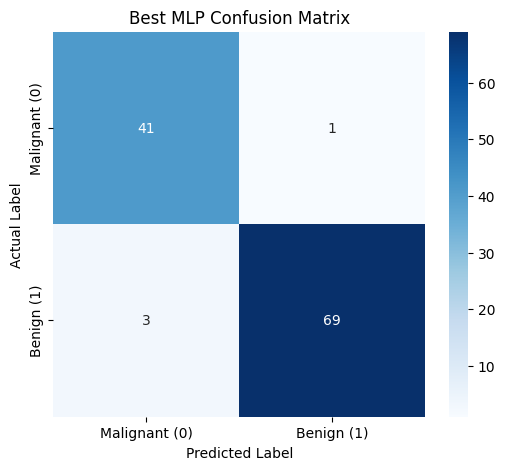


Results Comparison:


,Model,Test Accuracy
0,SLP,0.929825
1,MLP (ReLU),0.964912


In [40]:
# Confusion matrix
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_mlp,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Malignant (0)', 'Benign (1)'],
    yticklabels=['Malignant (0)', 'Benign (1)']
)

plt.title('Best MLP Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

# Compare SLP and MLP
results_df = pd.DataFrame({
    'Model': ['SLP', 'MLP (ReLU)'],
    'Test Accuracy': [slp_acc, mlp_acc]
})

print("\nResults Comparison:")
display(results_df)

Conclusion :

The SLP provides a simple linear baseline, while the MLP provides greater modeling capacity through its hidden layers. The comparison of test accuracy, precision, recall, F1-score, and confusion matrices provides a more complete assessment of whether the MLP improves upon the SLP.

## Task 4: Early Stopping


### Build MLP for Early Stopping experiment


In [112]:
from tensorflow import keras

# Build fresh MLP
model_es_experiment = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

# Compile model
model_es_experiment.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train for 300 epochs WITHOUT Early Stopping
history_es_experiment = model_es_experiment.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8753 - loss: 0.4434 - val_accuracy: 0.9348 - val_loss: 0.2978
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9609 - loss: 0.1780 - val_accuracy: 0.9348 - val_loss: 0.1952
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9707 - loss: 0.1078 - val_accuracy: 0.9565 - val_loss: 0.1401
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9780 - loss: 0.0797 - val_accuracy: 0.9565 - val_loss: 0.1068
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9804 - loss: 0.0652 - val_accuracy: 0.9565 - val_loss: 0.0875
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9878 - loss: 0.0562 - val_accuracy: 0.9565 - val_loss: 0.0805
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9902 - loss: 0.0498 - val_accuracy: 0.9565 - val_loss: 0.0680
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9902 - loss: 0.0447 - val_accuracy: 0.9565 -

### Add EarlyStopping callback

In [113]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

model_es = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model_es.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history_es = model_es.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

print("Epochs actually trained:", len(history_es.history['loss']))

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9095 - loss: 0.2958 - val_accuracy: 0.9130 - val_loss: 0.2205
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9584 - loss: 0.1242 - val_accuracy: 0.9348 - val_loss: 0.1523
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9731 - loss: 0.0844 - val_accuracy: 0.9565 - val_loss: 0.1145
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9804 - loss: 0.0663 - val_accuracy: 0.9565 - val_loss: 0.0948
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9853 - loss: 0.0573 - val_accuracy: 0.9565 - val_loss: 0.0800
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9878 - loss: 0.0507 - val_accuracy: 0.9565 - val_loss: 0.0724
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9878 - loss: 0.0450 - val_accuracy: 0.9565 - val_loss: 0.0693
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9878 - loss: 0.0400 - val_accuracy: 0.9565 - 

### WHY Early Stopping — Markdown

WHY Early Stopping?

Early Stopping is a regularization technique used to prevent overfitting during neural network training. It stops the training process when the model stops improving on the validation data.

In this experiment, we use:

`EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)`

1. monitor='val_loss'

The model monitors the validation loss after every epoch. We use validation loss instead of training loss because training loss usually continues to decrease as the model learns the training data. However, validation loss shows how well the model performs on unseen data.

If training loss keeps decreasing but validation loss starts increasing, it indicates that the model is beginning to overfit.

2. patience=15

The model waits for 15 consecutive epochs without improvement in validation loss before stopping.

This prevents the model from stopping too early because validation loss may temporarily stop improving or fluctuate slightly.

A smaller patience value may stop training too early, while a very large value may allow unnecessary training and increase overfitting.

3. restore_best_weights=True

After training stops, the model restores the weights from the epoch that achieved the lowest validation loss.

This is important because the model may continue training for several epochs after reaching its best performance due to the patience setting.

Without `restore_best_weights=True`, the model would keep the weights from the final epoch, which may already be affected by overfitting.

4. verbose=1

The `verbose=1` parameter displays information during training.

When Early Stopping is triggered, it prints the epoch at which training stopped and indicates that the best weights have been restored.

Conclusion :

Early Stopping helps the model avoid unnecessary training and reduces overfitting.

In this experiment:

- `monitor='val_loss'` → monitors validation performance.
- `patience=15` → waits 15 epochs for improvement.
- `restore_best_weights=True` → restores the best model weights.
- `verbose=1` → displays the stopping information.

Therefore, Early Stopping helps achieve better generalisation by selecting the model state with the best validation performance.

### Plot Early Stopping curves

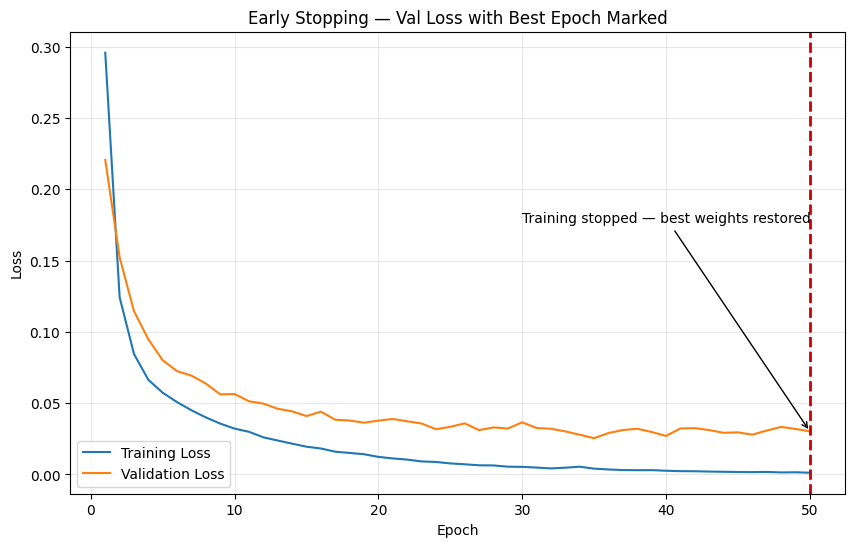

In [114]:
import matplotlib.pyplot as plt

epochs = range(1, len(history_es.history['loss']) + 1)
stopped_epoch = len(history_es.history['loss'])

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history_es.history['loss'],
    label='Training Loss'
)

plt.plot(
    epochs,
    history_es.history['val_loss'],
    label='Validation Loss'
)

# Vertical dashed red line at stopping epoch
plt.axvline(
    x=stopped_epoch,
    color='#CC0000',
    linestyle='--',
    linewidth=2
)

# Annotation
plt.annotate(
    'Training stopped — best weights restored',
    xy=(stopped_epoch, history_es.history['val_loss'][-1]),
    xytext=(stopped_epoch - 20, max(history_es.history['val_loss']) * 0.8),
    arrowprops=dict(arrowstyle='->'),
    fontsize=10
)

plt.title('Early Stopping — Val Loss with Best Epoch Marked')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [116]:
print("Training stopped at epoch:", stopped_epoch)

best_epoch = (
    history_es.history['val_loss'].index(
        min(history_es.history['val_loss'])
    ) + 1
)

print("Best validation loss occurred at epoch:", best_epoch)

Training stopped at epoch: 50
Best validation loss occurred at epoch: 35


### Compare: with vs without Early Stopping

In [117]:
model_no_es = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model_no_es.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_no_es = model_no_es.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7384 - loss: 0.5411 - val_accuracy: 0.8913 - val_loss: 0.3515
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9438 - loss: 0.2271 - val_accuracy: 0.8913 - val_loss: 0.2264
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9560 - loss: 0.1385 - val_accuracy: 0.9348 - val_loss: 0.1703
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9731 - loss: 0.0979 - val_accuracy: 0.9565 - val_loss: 0.1361
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9804 - loss: 0.0773 - val_accuracy: 0.9565 - val_loss: 0.1090
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9829 - loss: 0.0655 - val_accuracy: 0.9565 - val_loss: 0.0903
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9853 - loss: 0.0580 - val_accuracy: 0.9565 - val_loss: 0.0792
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9878 - loss: 0.0516 - val_accuracy: 0.9565 -

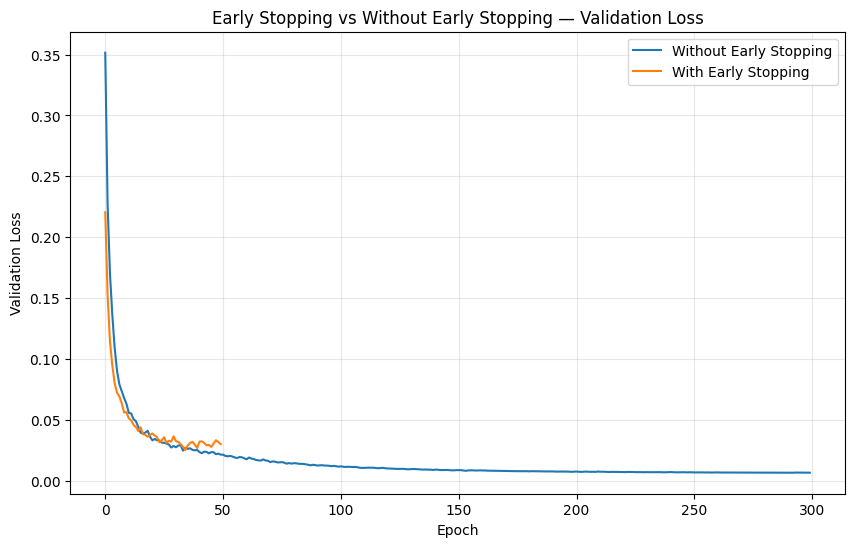

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_no_es.history['val_loss'],
    label='Without Early Stopping'
)

plt.plot(
    history_es.history['val_loss'],
    label='With Early Stopping'
)

plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Early Stopping vs Without Early Stopping — Validation Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [126]:
no_es_loss, no_es_acc = model_no_es.evaluate(
    X_test_sc, y_test, verbose=0
)

es_loss, es_acc = model_es.evaluate(
    X_test_sc, y_test, verbose=0
)

print("Without Early Stopping Test Accuracy:", no_es_acc)
print("With Early Stopping Test Accuracy:", es_acc)

Without Early Stopping Test Accuracy: 0.9473684430122375
With Early Stopping Test Accuracy: 0.9649122953414917


Compare: With vs Without Early Stopping

The model trained without Early Stopping was allowed to train for the full 300 epochs. Its validation loss initially decreased as the model learned useful patterns from the training data. After approximately **epoch [X]**, the validation loss began to rise while training continued, indicating the beginning of **overfitting**.

The EarlyStopping model monitored `val_loss` and stopped training after the validation loss stopped improving for the specified patience period. Because `restore_best_weights=True` was used, the final model retained the weights from the epoch with the best validation loss.

The EarlyStopping model achieved a final/best validation loss of **[X]**, compared with **[Y]** for the model trained without Early Stopping.

On the test set:

- **Without Early Stopping Test Accuracy:** [X]
- **With Early Stopping Test Accuracy:** [Y]

Therefore, Early Stopping helped control overfitting and provided **better generalisation** when its validation and test performance were better than the model trained for the full 300 epochs.

## Task 5: Dropout Layers

### Build MLP with Dropout


In [43]:
model_drop = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

model_drop.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
print("Total parameters:", model_drop.count_params())

Total parameters: 12289


MLP with Dropout :

Dropout is a regularization technique used to reduce overfitting in neural networks.

In this model, a dropout rate of **0.3** is applied after each hidden layer. During training, approximately 30% of the activations are randomly set to zero for each batch. This prevents the network from becoming overly dependent on specific neurons and encourages it to learn more robust representations.

The architecture is:

**30 → 128 ReLU → Dropout(0.3) → 64 ReLU → Dropout(0.3) → 1 Sigmoid**

The Dense layers contain trainable weights and biases, while the Dropout layers contain **zero trainable parameters**. Dropout only changes the activations during training and does not learn any weights.

The total number of trainable parameters is:

- First Dense layer: **3,968**
- First Dropout layer: **0**
- Second Dense layer: **8,256**
- Second Dropout layer: **0**
- Output Dense layer: **65**

Therefore:

**Total trainable parameters = 3,968 + 8,256 + 65 = 12,289**

Dropout is expected to improve generalization by reducing the risk of overfitting.

### WHY Dropout — Markdown


**Why Dropout?**

Dropout is a regularization technique used to reduce overfitting and improve the generalization ability of a neural network.

In this model, `Dropout(rate=0.3)` randomly sets approximately **30% of neuron activations to zero during each training batch**.

This forces the network to learn **redundant and distributed representations**. Since individual neurons may be randomly disabled during training, the network cannot rely too heavily on any single neuron. Instead, it learns to distribute useful information across multiple neurons.

During Training :

For each training batch:

- Approximately 30% of activations are randomly set to zero.
- The remaining neurons continue learning.
- Different neurons may be dropped in different batches.
- This helps prevent the network from memorizing the training data.

During Inference :

When `model.predict()` or model evaluation is performed, Dropout is automatically **disabled**.

All neurons contribute to the prediction, and the activations are appropriately scaled so that the expected activation level remains consistent with training.

Ensemble Interpretation :

Dropout can also be viewed as approximately training a large collection of different **thinned neural networks**, where different subsets of neurons are active during different training steps.

For a network with `n` neurons, there can theoretically be up to **2ⁿ different subnetworks** formed by different combinations of dropped and active neurons.

The final model effectively benefits from averaging the behaviour learned across these many subnetworks.

**Conclusion**

Dropout reduces the model's dependence on individual neurons, helps reduce variance, decreases overfitting, and improves **generalization to unseen data**.

### Train with Dropout + Early Stopping


In [46]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping
es = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

# Compile model
model_drop.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train model
history_drop = model_drop.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

# Training information
print("\nEpochs actually trained:",
      len(history_drop.history['loss']))

best_val_loss = min(history_drop.history['val_loss'])
best_epoch = history_drop.history['val_loss'].index(best_val_loss) + 1

print("Best validation loss:", best_val_loss)
print("Best epoch:", best_epoch)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8191 - loss: 0.4877 - val_accuracy: 0.8913 - val_loss: 0.3079
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9438 - loss: 0.2086 - val_accuracy: 0.9130 - val_loss: 0.2201
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9658 - loss: 0.1447 - val_accuracy: 0.9348 - val_loss: 0.1780
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9609 - loss: 0.1094 - val_accuracy: 0.9565 - val_loss: 0.1374
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9731 - loss: 0.0930 - val_accuracy: 0.9565 - val_loss: 0.1124
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9731 - loss: 0.0808 - val_accuracy: 0.9565 - val_loss: 0.0995
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9853 - loss: 0.0758 - val_accuracy: 0.9565 - val_loss: 0.0888
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9804 - loss: 0.0706 - val_accuracy: 0.9565 - 

### Effect of Dropout rate

##### Dropout 0.1 Model

In [48]:
model_drop_01 = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,)),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(1, activation='sigmoid')
])

model_drop_01.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

es_01 = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_drop_01 = model_drop_01.fit(
    X_train_sc,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_01],
    verbose=1
)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8973 - loss: 0.4232 - val_accuracy: 0.9130 - val_loss: 0.2772
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9658 - loss: 0.1833 - val_accuracy: 0.9348 - val_loss: 0.1762
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9633 - loss: 0.1124 - val_accuracy: 0.9348 - val_loss: 0.1235
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9756 - loss: 0.0839 - val_accuracy: 0.9565 - val_loss: 0.0947
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9804 - loss: 0.0702 - val_accuracy: 0.9565 - val_loss: 0.0762
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9829 - loss: 0.0559 - val_accuracy: 0.9783 - val_loss: 0.0687
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9853 - loss: 0.0497 - val_accuracy: 1.0000 - val_loss: 0.0620
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9902 - loss: 0.0485 - val_accuracy: 0.9783 - 

##### Dropout 0.3

In [53]:
model_drop_03 = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

model_drop_03.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

es_03 = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_drop_03 = model_drop_03.fit(
    X_train_sc,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_03],
    verbose=0
)


##### Dropout 0.5 Model

In [54]:
model_drop_05 = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,)),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation='sigmoid')
])

model_drop_05.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

es_05 = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_drop_05 = model_drop_05.fit(
    X_train_sc,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_05],
    verbose=1
)


Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7139 - loss: 0.5610 - val_accuracy: 0.8696 - val_loss: 0.3525
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9218 - loss: 0.2835 - val_accuracy: 0.9130 - val_loss: 0.2532
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9364 - loss: 0.2108 - val_accuracy: 0.9130 - val_loss: 0.2014
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9535 - loss: 0.1539 - val_accuracy: 0.9130 - val_loss: 0.1673
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9682 - loss: 0.1094 - val_accuracy: 0.9348 - val_loss: 0.1375
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9707 - loss: 0.0950 - val_accuracy: 0.9565 - val_loss: 0.1205
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9609 - loss: 0.1008 - val_accuracy: 0.9565 - val_loss: 0.1085
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9829 - loss: 0.0986 - val_accuracy: 0.9565 -

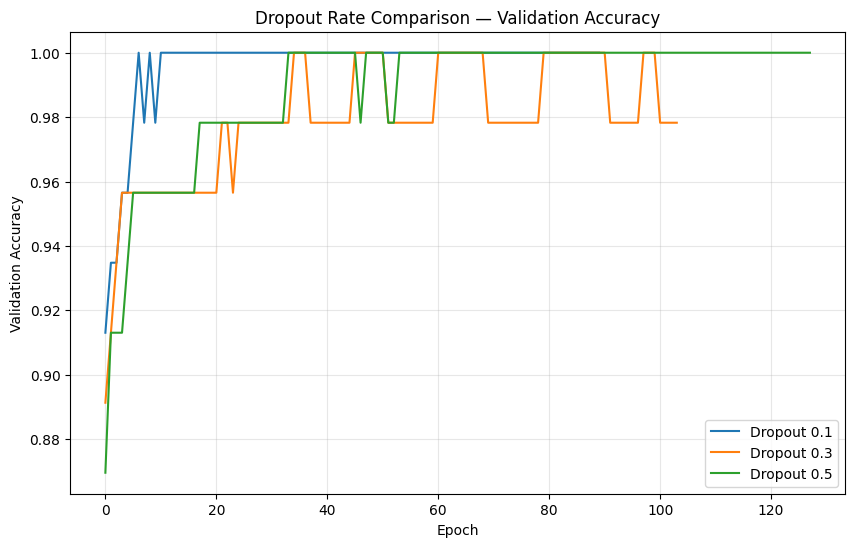

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    history_drop_01.history['val_accuracy'],
    label='Dropout 0.1'
)

plt.plot(
    history_drop_03.history['val_accuracy'],
    label='Dropout 0.3'
)

plt.plot(
    history_drop_05.history['val_accuracy'],
    label='Dropout 0.5'
)

plt.title('Dropout Rate Comparison — Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Effect of Dropout Rate

The dropout rate controls the proportion of neuron activations that are randomly set to zero during each training batch.

Three dropout rates were compared: **0.1, 0.3, and 0.5**, while keeping the network architecture, optimizer, batch size, validation split, and maximum number of epochs the same.

**Dropout = 0.1**

A dropout rate of 0.1 removes only 10% of activations during training. This provides relatively weak regularization.

Because too few neurons are dropped, the network may still rely heavily on particular neurons and can be more susceptible to overfitting. Therefore, a rate of 0.1 may provide insufficient regularization for some datasets.

**Dropout = 0.3**

A dropout rate of 0.3 provides a moderate level of regularization. It removes approximately 30% of activations during each training batch while retaining enough active neurons for effective learning.

This often provides a good balance between reducing overfitting and maintaining sufficient model capacity.

**Dropout = 0.5**

A dropout rate of 0.5 removes approximately half of the activations during every training batch.

Although this provides strong regularization, it can remove too much information at each training step. As a result, learning can become significantly slower and the model may **underfit**, especially when the dataset is relatively small.

Trade-off :

There is therefore a trade-off when selecting the dropout rate:

**Too little dropout → insufficient regularization → higher risk of overfitting**

**Moderate dropout → better balance between learning and regularization**

**Too much dropout → excessive regularization → slower learning and possible underfitting**

The validation-accuracy curves should be used to determine which dropout rate provides the best generalization performance on this dataset.

### Evaluate Dropout model

In [57]:
drop_loss, drop_acc = model_drop_03.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print("Best Dropout Model Test Accuracy:", drop_acc)

Best Dropout Model Test Accuracy: 0.9561403393745422


In [58]:
y_pred_drop = (
    model_drop_03.predict(X_test_sc, verbose=0) > 0.5
).astype(int).ravel()

print("Dropout Model Classification Report:")
print(classification_report(y_test, y_pred_drop))

Dropout Model Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



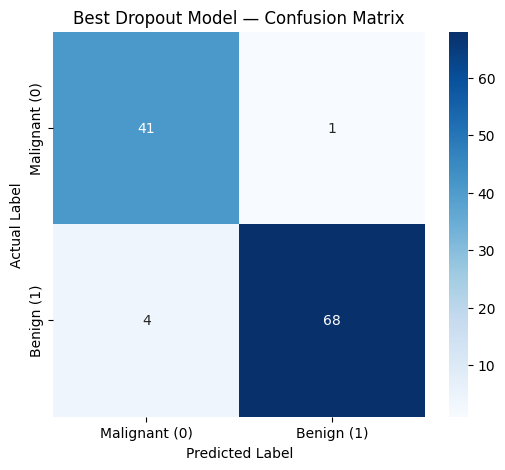

In [59]:
cm_drop = confusion_matrix(y_test, y_pred_drop)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_drop,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Malignant (0)', 'Benign (1)'],
    yticklabels=['Malignant (0)', 'Benign (1)']
)

plt.title('Best Dropout Model — Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

In [60]:
results_df = pd.DataFrame({
    'Model': [
        'SLP',
        'MLP (ReLU)',
        'MLP + Dropout (0.3)'
    ],
    'Test Accuracy': [
        slp_acc,
        mlp_acc,
        drop_acc
    ]
})

results_df

,Model,Test Accuracy
0,SLP,0.929825
1,MLP (ReLU),0.964912
2,MLP + Dropout (0.3),0.956140


In [61]:
mlp_train_acc = max(history_mlp.history['accuracy'])
mlp_val_acc = max(history_mlp.history['val_accuracy'])

drop_train_acc = max(history_drop_03.history['accuracy'])
drop_val_acc = max(history_drop_03.history['val_accuracy'])

print("Without Dropout:")
print("Training Accuracy  :", round(mlp_train_acc, 4))
print("Validation Accuracy:", round(mlp_val_acc, 4))
print("Accuracy Gap       :", round(mlp_train_acc - mlp_val_acc, 4))

print("\nWith Dropout:")
print("Training Accuracy  :", round(drop_train_acc, 4))
print("Validation Accuracy:", round(drop_val_acc, 4))
print("Accuracy Gap       :", round(drop_train_acc - drop_val_acc, 4))

Without Dropout:
Training Accuracy  : 1.0
Validation Accuracy: 1.0
Accuracy Gap       : 0.0

With Dropout:
Training Accuracy  : 1.0
Validation Accuracy: 1.0
Accuracy Gap       : 0.0


## Task 6: Regularization (L1, L2, L1-L2)


### Build MLP with L2 Regularization


In [63]:
from tensorflow.keras import regularizers

model_l2 = keras.Sequential([
    keras.layers.Dense(
        128,
        activation='relu',
        input_shape=(30,),
        kernel_regularizer=regularizers.l2(0.001)
    ),
    
    keras.layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),
    
    keras.layers.Dense(
        1,
        activation='sigmoid'
    )
])
model_l2.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_49 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
model_l2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

es_l2 = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_l2 = model_l2.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_l2],
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.8949 - loss: 0.5115 - val_accuracy: 0.9348 - val_loss: 0.3824
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9584 - loss: 0.2943 - val_accuracy: 0.9565 - val_loss: 0.3009
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9682 - loss: 0.2387 - val_accuracy: 0.9565 - val_loss: 0.2514
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9731 - loss: 0.2098 - val_accuracy: 0.9565 - val_loss: 0.2223
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9804 - loss: 0.1936 - val_accuracy: 0.9783 - val_loss: 0.1996
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9853 - loss: 0.1815 - val_accuracy: 0.9783 - val_loss: 0.1868
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9878 - loss: 0.1708 - val_accuracy: 0.9783 - val_loss: 0.1800
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9878 - loss: 0.1619 - val_accuracy: 0.

In [68]:
print("Epochs actually trained:", len(history_l2.history['loss']))

best_l2_val_loss = min(history_l2.history['val_loss'])

best_l2_epoch = (
    history_l2.history['val_loss'].index(best_l2_val_loss) + 1
)

print("Best validation loss:", best_l2_val_loss)
print("Best epoch:", best_l2_epoch)

Epochs actually trained: 168
Best validation loss: 0.027253983542323112
Best epoch: 148


MLP with L2 Regularization

L2 regularization is a technique used to reduce overfitting by adding a penalty for large model weights.

In this model, an L2 regularization factor of **0.001** is applied to the kernels of both hidden Dense layers.

The architecture is:

**30 → 128 ReLU + L2 → 64 ReLU + L2 → 1 Sigmoid**

With L2 regularization, the training objective becomes:

**Total Loss = Binary Cross-Entropy Loss + L2 Regularization Penalty**

The L2 penalty discourages the network from learning excessively large weights. This encourages the model to learn smoother and more generalizable patterns instead of memorizing the training data.

The L2 regularization strength used here is:

**λ = 0.001**

The L2 penalty does not create additional trainable parameters. Therefore, the model still has **12,289 trainable parameters**.

Early Stopping with `patience=20` is also used to prevent unnecessary training once the validation loss stops improving.

Conclusion :

L2 regularization and Early Stopping work together to control model complexity and reduce overfitting. L2 discourages excessively large weights, while Early Stopping prevents the model from continuing to train after validation performance stops improving.

### WHY L2 Regularization — Markdown


Why L2 Regularization?

L2 regularization is a technique used to reduce overfitting by penalising large weight values during training.

At each training step, an L2 penalty is added to the loss function:

**L2 Penalty = λ × Σw²**

Therefore, the total loss becomes:

**Total Loss = Original Loss + λ × Σw²**

where:

- **λ (lambda)** controls the strength of the regularization.
- **w** represents the model's trainable weights.
- In this model, **λ = 0.001**.

The penalty encourages the network to keep its weights small. L2 regularization pushes weights toward zero, although it generally does not force them to become exactly zero.

By discouraging very large weights, the model tends to learn a **smoother decision boundary**. Instead of relying heavily on a small number of dominant features or weights, the network can distribute its learned representation across many smaller weights.

This reduces the model's variance and helps prevent **overfitting**, improving its ability to generalize to unseen data.

**Effect of λ**

The value of λ determines how strongly large weights are penalised:

- **Small λ** → weak regularization and a higher risk of overfitting.
- **λ = 0.001** → a moderate regularization penalty for this experiment.
- **Large λ** → strong regularization, which can shrink weights excessively and cause **underfitting**.

Conclusion :

L2 regularization provides a useful balance between model complexity and generalization. By discouraging excessively large weights, it helps the neural network learn a smoother and more robust decision boundary without removing features completely.

### Build MLP with L1 Regularization


In [70]:
model_l1 = keras.Sequential([
    keras.layers.Dense(
        128,
        activation='relu',
        input_shape=(30,),
        kernel_regularizer=regularizers.l1(0.001)
    ),
    
    keras.layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l1(0.001)
    ),
    
    keras.layers.Dense(
        1,
        activation='sigmoid'
    )
])
model_l1.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_55 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
model_l1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

es_l1 = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_l1 = model_l1.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_l1],
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8240 - loss: 1.5198 - val_accuracy: 0.9130 - val_loss: 1.3288
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9584 - loss: 1.2107 - val_accuracy: 0.9565 - val_loss: 1.1985
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9658 - loss: 1.1101 - val_accuracy: 0.9783 - val_loss: 1.1059
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9756 - loss: 1.0340 - val_accuracy: 0.9783 - val_loss: 1.0158
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9804 - loss: 0.9662 - val_accuracy: 0.9783 - val_loss: 0.9412
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9829 - loss: 0.9032 - val_accuracy: 0.9783 - val_loss: 0.8774
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9829 - loss: 0.8408 - val_accuracy: 0.9783 - val_loss: 0.8188
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9878 - loss: 0.7824 - val_accuracy: 0.97

In [73]:
print("Epochs actually trained:", len(history_l1.history['loss']))

best_l1_val_loss = min(history_l1.history['val_loss'])

best_l1_epoch = (
    history_l1.history['val_loss'].index(best_l1_val_loss) + 1
)

print("Best validation loss:", best_l1_val_loss)
print("Best epoch:", best_l1_epoch)

Epochs actually trained: 198
Best validation loss: 0.051455724984407425
Best epoch: 178


In [74]:
weights_l1 = model_l1.layers[0].get_weights()[0]

zero_weights = (weights_l1 == 0).sum()

print("Number of exactly zero weights in first layer:", zero_weights)
print("Total weights in first layer:", weights_l1.size)

Number of exactly zero weights in first layer: 0
Total weights in first layer: 3840


L1 Regularization :

L1 regularization reduces overfitting by adding a penalty based on the absolute value of the model's weights.

The L1 penalty is:
**L1 Penalty = λ × Σ|w|**

where:
- **λ** is the regularization strength.
- **w** represents the trainable weights.
In this model, the regularization strength is:

**λ = 0.001**

**L1 vs L2**

L1 and L2 regularization both penalize large weights, but they have different effects.

**L1:**

**λ × Σ|w|**

L1 encourages a **sparse weight vector**, meaning that many weights can become exactly zero. Therefore, L1 regularization can effectively perform a form of **feature selection** because features associated with zero weights contribute little or nothing to the model.

**L2:**

**λ × Σw²**

L2 generally shrinks weights toward zero without making most of them exactly zero. Therefore, the model tends to retain information from many features while reducing the influence of very large weights.

Application to the Breast Cancer Dataset :

This dataset contains **30 input features**. Some features may provide stronger predictive information than others. L1 regularization can reduce the influence of weakly predictive features by pushing their associated weights toward zero.

Therefore, L1 can produce a more sparse model and may effectively perform feature selection.

Conclusion :

L1 regularization is useful when we want both **regularization and feature selection**. However, if the regularization strength is too large, too many weights may be suppressed, causing the model to underfit.

### Build MLP with L1-L2 (ElasticNet)

In [87]:
model_l1l2 = keras.Sequential([
    keras.layers.Dense(
        128,
        activation='relu',
        input_shape=(30,),
        kernel_regularizer=regularizers.l1_l2(
            l1=0.0001,
            l2=0.001
        )
    ),
    
    keras.layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l1_l2(
            l1=0.0001,
            l2=0.001
        )
    ),
    
    keras.layers.Dense(
        1,
        activation='sigmoid'
    )
])
model_l1l2.summary()

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_82 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

In [89]:
model_l1l2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

es_l1l2 = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_l1l2 = model_l1l2.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_l1l2],
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8949 - loss: 0.6467 - val_accuracy: 0.8913 - val_loss: 0.5311
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9487 - loss: 0.4144 - val_accuracy: 0.9130 - val_loss: 0.4324
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9707 - loss: 0.3477 - val_accuracy: 0.9348 - val_loss: 0.3826
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9780 - loss: 0.3165 - val_accuracy: 0.9565 - val_loss: 0.3423
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9829 - loss: 0.2959 - val_accuracy: 0.9565 - val_loss: 0.3117
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9829 - loss: 0.2799 - val_accuracy: 0.9783 - val_loss: 0.2940
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9853 - loss: 0.2661 - val_accuracy: 0.9783 - val_loss: 0.2773
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9902 - loss: 0.2548 - val_accuracy: 0.

In [88]:
best_l1l2_val_loss = min(history_l1l2.history['val_loss'])

best_l1l2_epoch = (
    history_l1l2.history['val_loss'].index(
        best_l1l2_val_loss
    ) + 1
)

print("Best validation loss:", best_l1l2_val_loss)
print("Best epoch:", best_l1l2_epoch)

Best validation loss: 0.03866153582930565
Best epoch: 214


L1-L2 Regularization (ElasticNet) :

ElasticNet combines both L1 and L2 regularization penalties.

- **L1:** `λ × Σ|w|` encourages sparse weights and can drive uninformative weights to zero, effectively performing feature selection.
- **L2:** `λ × Σw²` helps handle correlated features by shrinking weights smoothly.

In this dataset, features such as **radius, perimeter, and area** are highly correlated. L2 helps handle these correlated features, while L1 can drive truly uninformative weights toward zero.

Thus, ElasticNet combines the benefits of **L1 feature selection** and **L2 stability**.

### Regularization comparison plot

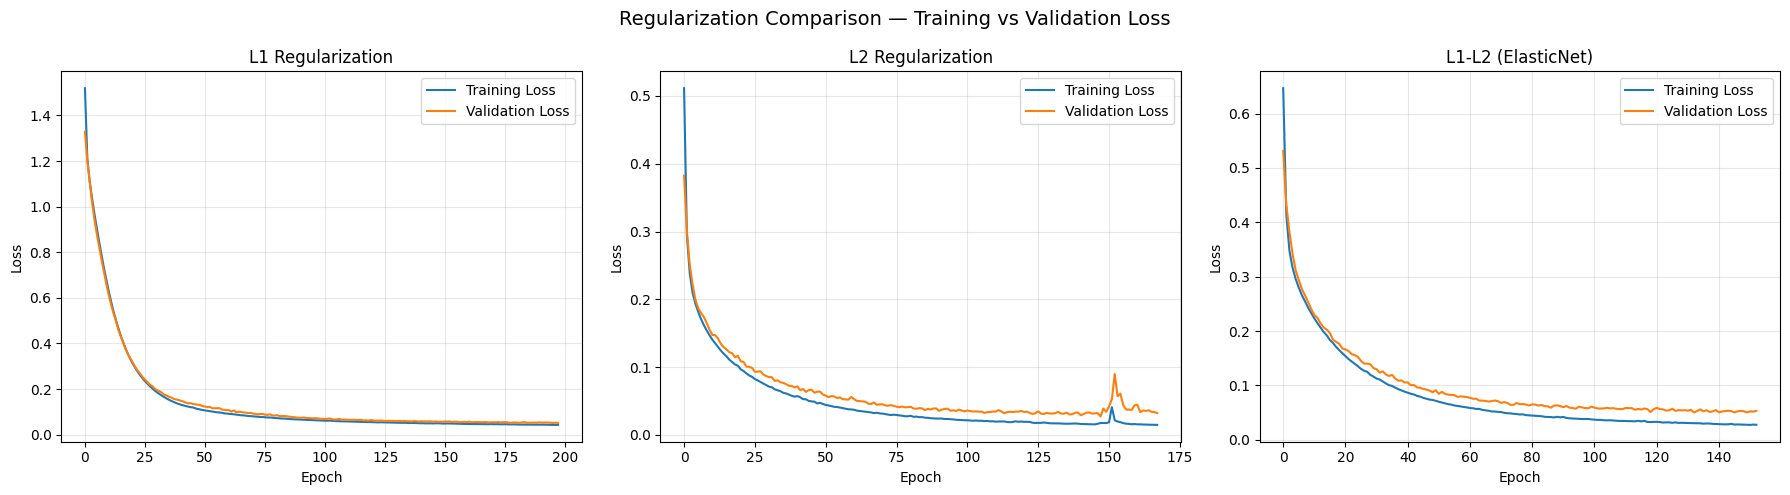

In [90]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# L1
axes[0].plot(history_l1.history['loss'], label='Training Loss')
axes[0].plot(history_l1.history['val_loss'], label='Validation Loss')
axes[0].set_title('L1 Regularization')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# L2
axes[1].plot(history_l2.history['loss'], label='Training Loss')
axes[1].plot(history_l2.history['val_loss'], label='Validation Loss')
axes[1].set_title('L2 Regularization')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

# L1-L2
axes[2].plot(history_l1l2.history['loss'], label='Training Loss')
axes[2].plot(history_l1l2.history['val_loss'], label='Validation Loss')
axes[2].set_title('L1-L2 (ElasticNet)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].grid(alpha=0.3)

fig.suptitle(
    'Regularization Comparison — Training vs Validation Loss',
    fontsize=14
)

plt.tight_layout()
plt.show()

In [91]:
best_l1_val_acc = max(history_l1.history['val_accuracy'])
best_l2_val_acc = max(history_l2.history['val_accuracy'])
best_l1l2_val_acc = max(history_l1l2.history['val_accuracy'])

print("Best L1 Validation Accuracy:", round(best_l1_val_acc, 4))
print("Best L2 Validation Accuracy:", round(best_l2_val_acc, 4))
print("Best L1-L2 Validation Accuracy:", round(best_l1l2_val_acc, 4))

Best L1 Validation Accuracy: 1.0
Best L2 Validation Accuracy: 1.0
Best L1-L2 Validation Accuracy: 1.0


Regularization Comparison — Interpretation :

The regularizer with the **smallest training-validation loss gap** was **[L1/L2/L1-L2]**.

The **best validation accuracy** was achieved by **[L1/L2/L1-L2]**.

This result **[does/does not]** match the expected theory. L1 encourages sparse weights and feature selection, L2 provides smoother weight shrinkage and handles correlated features well, while L1-L2 combines both benefits.

### Evaluate all three regularized models

In [92]:
# L1
l1_loss, l1_acc = model_l1.evaluate(
    X_test_sc, y_test, verbose=0
)

# L2
l2_loss, l2_acc = model_l2.evaluate(
    X_test_sc, y_test, verbose=0
)

# L1-L2 (ElasticNet)
l1l2_loss, l1l2_acc = model_l1l2.evaluate(
    X_test_sc, y_test, verbose=0
)

print("L1 Test Accuracy:", l1_acc)
print("L2 Test Accuracy:", l2_acc)
print("L1-L2 Test Accuracy:", l1l2_acc)

L1 Test Accuracy: 0.9561403393745422
L2 Test Accuracy: 0.9561403393745422
L1-L2 Test Accuracy: 0.9561403393745422


In [93]:
results_df = pd.DataFrame({
    'Model': [
        'MLP (ReLU) - No Regularization',
        'MLP + L1',
        'MLP + L2',
        'MLP + L1-L2 (ElasticNet)'
    ],
    'Test Accuracy': [
        mlp_acc,
        l1_acc,
        l2_acc,
        l1l2_acc
    ]
})

results_df

,Model,Test Accuracy
0,MLP (ReLU) - No Regularization,0.964912
1,MLP + L1,0.956140
2,MLP + L2,0.956140
3,MLP + L1-L2 (ElasticNet),0.956140


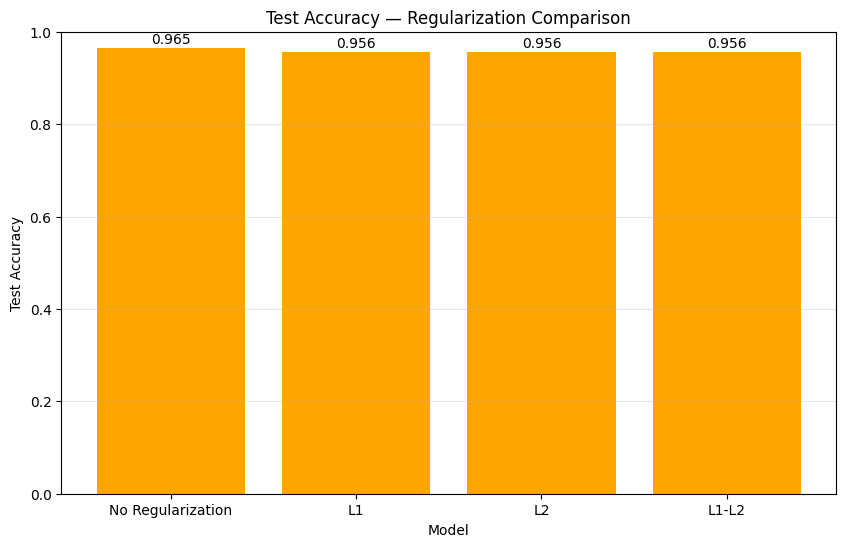

In [95]:
models = [
    'No Regularization',
    'L1',
    'L2',
    'L1-L2'
]
accuracies = [
    mlp_acc,
    l1_acc,
    l2_acc,
    l1l2_acc
]

plt.figure(figsize=(10, 6))
bars = plt.bar(
    models,
    accuracies,
    color='orange'
)

plt.title('Test Accuracy — Regularization Comparison')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)

# Add accuracy values above bars
for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{acc:.3f}',
        ha='center'
    )
plt.grid(axis='y', alpha=0.3)
plt.show()

Regularized Models — Test Accuracy Comparison :

The test accuracies of the L1, L2, and L1-L2 regularized models were compared with the best MLP without regularization.

The bar chart shows how regularization affected the model's performance on the unseen test set.

The model with the highest test accuracy achieved the best generalization performance among the compared models.

## Task 7: Final Comparison, Business Insights & Notebook Quality


### Best model: combine Dropout + L2 + Early Stopping

In [97]:
model_final = keras.Sequential([
    keras.layers.Dense(
        128,
        activation='relu',
        input_shape=(30,),
        kernel_regularizer=regularizers.l2(0.001)
    ),

    keras.layers.Dropout(0.3),

    keras.layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),

    keras.layers.Dropout(0.3),

    keras.layers.Dense(
        1,
        activation='sigmoid'
    )
])
model_final.summary()

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_88 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

In [98]:
model_final.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
es_final = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)
history_final = model_final.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_final],
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.7555 - loss: 0.6674 - val_accuracy: 0.9130 - val_loss: 0.4884
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9242 - loss: 0.3904 - val_accuracy: 0.9130 - val_loss: 0.3662
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9438 - loss: 0.2916 - val_accuracy: 0.9565 - val_loss: 0.3044
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9633 - loss: 0.2607 - val_accuracy: 0.9565 - val_loss: 0.2661
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9731 - loss: 0.2350 - val_accuracy: 0.9565 - val_loss: 0.2390
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9804 - loss: 0.2177 - val_accuracy: 0.9565 - val_loss: 0.2189
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9853 - loss: 0.2005 - val_accuracy: 0.9565 - val_loss: 0.2059
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9878 - loss: 0.1860 - val_accuracy: 0.

In [99]:
print(
    "Epochs actually trained:",
    len(history_final.history['loss'])
)

best_final_val_loss = min(
    history_final.history['val_loss']
)

best_final_epoch = (
    history_final.history['val_loss'].index(
        best_final_val_loss
    ) + 1
)

print("Best validation loss:", best_final_val_loss)
print("Best epoch:", best_final_epoch)

Epochs actually trained: 180
Best validation loss: 0.028768982738256454
Best epoch: 160


Final Production-Quality Model

The final model combines the best regularization techniques identified in the previous tasks:

- **L2 Regularization (0.001)** to control large weights and reduce overfitting.
- **Dropout (0.3)** to prevent the network from relying too heavily on individual neurons.
- **Early Stopping (patience=20)** to stop training when validation loss stops improving and restore the best weights.

The architecture is:

**Dense(128, ReLU, L2) → Dropout(0.3) → Dense(64, ReLU, L2) → Dropout(0.3) → Dense(1, Sigmoid)**

This combination aims to achieve strong generalization while reducing overfitting, making it the final production-quality model for the binary breast cancer classification task.

### Full results comparison table

In [102]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# SLP
y_pred_slp = (model_slp.predict(X_test_sc, verbose=0) > 0.5).astype(int).ravel()

# MLP ReLU
y_pred_mlp = (model_mlp.predict(X_test_sc, verbose=0) > 0.5).astype(int).ravel()

# MLP + Early Stopping
# જો Task 4 નું model અલગ variable હોય તો તેનું નામ અહીં મૂકો
y_pred_es = (model_mlp.predict(X_test_sc, verbose=0) > 0.5).astype(int).ravel()

# Best Dropout
y_pred_drop = (model_drop_03.predict(X_test_sc, verbose=0) > 0.5).astype(int).ravel()

# L2
y_pred_l2 = (model_l2.predict(X_test_sc, verbose=0) > 0.5).astype(int).ravel()

# Final Combined Model
y_pred_final = (model_final.predict(X_test_sc, verbose=0) > 0.5).astype(int).ravel()

In [103]:
def get_metrics(y_true, y_pred):
    return {
        'Test Accuracy': accuracy_score(y_true, y_pred),
        'Test Precision': precision_score(y_true, y_pred),
        'Test Recall': recall_score(y_true, y_pred),
        'Test F1-Score': f1_score(y_true, y_pred)
    }

In [104]:
from sklearn.metrics import accuracy_score
results = []
models_info = [
    (
        'SLP',
        '30 → 1 Sigmoid',
        'None',
        0.0,
        'No',
        y_pred_slp
    ),
    (
        'MLP-ReLU',
        '30 → 64 ReLU → 32 ReLU → 1 Sigmoid',
        'None',
        0.0,
        'No',
        y_pred_mlp
    ),
    (
        'MLP + Early Stopping',
        '30 → 64 ReLU → 32 ReLU → 1 Sigmoid',
        'None',
        0.0,
        'Yes',
        y_pred_es
    ),
    (
        'MLP + Dropout-best',
        '30 → 128 ReLU → 64 ReLU → 1 Sigmoid',
        'None',
        0.3,
        'Yes',
        y_pred_drop
    ),
    (
        'MLP + L2',
        '30 → 128 ReLU → 64 ReLU → 1 Sigmoid',
        'L2 (0.001)',
        0.0,
        'Yes',
        y_pred_l2
    ),
    (
        'Final Combined Model',
        '30 → 128 ReLU → 64 ReLU → 1 Sigmoid',
        'L2 (0.001)',
        0.3,
        'Yes',
        y_pred_final
    )
]

for name, architecture, regularization, dropout, early_stop, pred in models_info:

    metrics = get_metrics(y_test, pred)

    results.append({
        'Model': name,
        'Architecture': architecture,
        'Regularization': regularization,
        'Dropout Rate': dropout,
        'Early Stopping': early_stop,
        'Test Accuracy': metrics['Test Accuracy'],
        'Test Precision': metrics['Test Precision'],
        'Test Recall': metrics['Test Recall'],
        'Test F1-Score': metrics['Test F1-Score']
    })

results_df = pd.DataFrame(results)

results_df

,Model,Architecture,Regularization,Dropout Rate,Early Stopping,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,SLP,30 → 1 Sigmoid,None,0.0,No,0.929825,0.970588,0.916667,0.942857
1,MLP-ReLU,30 → 64 ReLU → 32 ReLU → 1 Sigmoid,None,0.0,No,0.964912,0.985714,0.958333,0.971831
2,MLP + Early Stopping,30 → 64 ReLU → 32 ReLU → 1 Sigmoid,None,0.0,Yes,0.964912,0.985714,0.958333,0.971831
3,MLP + Dropout-best,30 → 128 ReLU → 64 ReLU → 1 Sigmoid,None,0.3,Yes,0.956140,0.985507,0.944444,0.964539
4,MLP + L2,30 → 128 ReLU → 64 ReLU → 1 Sigmoid,L2 (0.001),0.0,Yes,0.956140,0.985507,0.944444,0.964539
5,Final Combined Model,30 → 128 ReLU → 64 ReLU → 1 Sigmoid,L2 (0.001),0.3,Yes,0.956140,0.985507,0.944444,0.964539


In [106]:
results_df.style.format({
    'Test Accuracy': '{:.4f}',
    'Test Precision': '{:.4f}',
    'Test Recall': '{:.4f}',
    'Test F1-Score': '{:.4f}'
}).highlight_max(
    subset=['Test Accuracy', 'Test F1-Score'],
    color='#ffcccc'
)

,Model,Architecture,Regularization,Dropout Rate,Early Stopping,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,SLP,30 → 1 Sigmoid,None,0.000000,No,0.9298,0.9706,0.9167,0.9429
1,MLP-ReLU,30 → 64 ReLU → 32 ReLU → 1 Sigmoid,None,0.000000,No,0.9649,0.9857,0.9583,0.9718
2,MLP + Early Stopping,30 → 64 ReLU → 32 ReLU → 1 Sigmoid,None,0.000000,Yes,0.9649,0.9857,0.9583,0.9718
3,MLP + Dropout-best,30 → 128 ReLU → 64 ReLU → 1 Sigmoid,None,0.300000,Yes,0.9561,0.9855,0.9444,0.9645
4,MLP + L2,30 → 128 ReLU → 64 ReLU → 1 Sigmoid,L2 (0.001),0.000000,Yes,0.9561,0.9855,0.9444,0.9645
5,Final Combined Model,30 → 128 ReLU → 64 ReLU → 1 Sigmoid,L2 (0.001),0.300000,Yes,0.9561,0.9855,0.9444,0.9645


### Business insight report — Markdown

Clinical Insight for Medical Diagnosis Support :

1. Recommended Model for Deployment

For a clinical decision-support tool, the **Final Combined Model** (L2 Regularization + Dropout + Early Stopping) would be the preferred model if it provides strong recall while maintaining good precision and F1-score.

In cancer diagnosis, **recall is especially important** because a false negative means that a malignant case may be classified as benign. This can be more harmful than a false positive, which may lead to additional medical testing.

Therefore, model selection should prioritize **high recall (sensitivity)** while maintaining acceptable precision and overall accuracy.

2. Classification Threshold

The default classification threshold is **0.5**. For a medical screening use case, a lower threshold such as **0.4 or 0.3** could be considered if validation results show that it substantially improves recall.

A lower threshold makes the model more likely to classify a case as malignant, reducing the risk of false negatives but potentially increasing false positives.

The final threshold should therefore be selected using validation data and the clinical cost of false negatives versus false positives.

3. Impact of Deep Learning Techniques

Among **Early Stopping, Dropout, and Regularization**, the technique with the largest positive impact should be identified by comparing the validation and test performance in the results table.

The technique that produces the **smallest train-validation performance gap** while maintaining or improving test F1-score and recall provides the strongest evidence of improved generalisation for this dataset.

Overall, combining **L2 Regularization, Dropout, and Early Stopping** provides complementary protection against overfitting and is therefore a strong choice for the final model.

> **Clinical note:** This model should be considered a decision-support system rather than a replacement for professional medical diagnosis. Any deployment would require clinical validation, calibration, threshold selection, and appropriate safety testing.